## Part 3: State of Art Comparison
Objective: Benchmark your model against the SOA with the full dataset now available

Although we saw in Part 2 that SetFit performed better than BERT. Part two was testing with limited dataset. Now we would be running with up to over 10,000 rows of real data. Running it for this problem, we expect that SetFit will run better than BERT on the small percentages (1%, 10%) of the total data like we saw in Part 2 but after a certain percentages BERT will start to perform better. This is because SetFit works best with sparse data. SetFit's whole purpose is few-shot learning — squeezing signal out of tens of labeled examples by generating contrastive pairs. Its key mechanism, the contrastive pair generation, scales badly with data. We expect SetFit's advantage to shrink as data grows. At 100% of your dataset (our best model), standard BERT likely matches or beats SetFit. At 10k examples, SetFit is simultaneously much slower and pointless -- we'd be paying a huge computational cost for a technique whose advantage (data efficiency) is irrelevant when data is abundant.

### a. Full Dataset Training (0.25 points):
Incrementally train your model with varying percentages of the full dataset (1%, 10%, 25%, 50%, 75%,
and 100%). Record the results.

In [11]:
from pathlib import Path
import random
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
import torch

PROJECT_ROOT = Path.cwd().parent          # notebooks/ -> repo root
sys.path.insert(0, str(PROJECT_ROOT))                 # enables ⁠ from scripts.X import ... ⁠
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))     # enables bare ⁠ import utils ⁠, ⁠ from setup 

from scripts.Part_2_BERT import train_bert, evaluate_with_kfold
from scripts.utils import Metrics, preprocess_for_tfidf, preprocess_for_bert
import time
from sklearn.model_selection import StratifiedKFold
import gc #gc is used to free up memory after each fold of cross-validation, which is important when working with large models like BERT to prevent memory leaks and ensure efficient resource usage.
import json 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


Skipping import of cpp extensions due to incompatible torch version 2.12.0 for torchao version 0.15.0             Please see https://github.com/pytorch/ao/issues/2919 for more info
W0618 19:47:51.219000 7206 .venv/lib/python3.12/site-packages/torch/distributed/elastic/multiprocessing/redirects.py:35] NOTE: Redirects are currently not supported in MacOs.


In [13]:
import json
from pathlib import Path

DATA_DIR = PROJECT_ROOT / "data"

def load_checkpoint(path):
    if path.exists():
        with open(path, 'r') as f:
            return json.load(f)
    return {}

base_results = load_checkpoint(DATA_DIR / 'results_checkpoint_BERT.json')
augmented_results = load_checkpoint(DATA_DIR / 'results_checkpoint_BERT_augmented.json')
synthetic_results = load_checkpoint(DATA_DIR / 'results_checkpoint_BERT_synthetic.json')

print(list(base_results.keys()))
print(list(augmented_results.keys()))
print(list(synthetic_results.keys()))

['BERT_10%', 'BERT_25%', 'BERT_50%', 'BERT_1%', 'BERT_75%', 'BERT_100%']
['BERT_augmented_1%', 'BERT_augmented_10%', 'BERT_augmented_25%', 'BERT_augmented_50%', 'BERT_augmented_75%', 'BERT_augmented_100%']
['BERT_synthetic_1%', 'BERT_synthetic_10%', 'BERT_synthetic_25%', 'BERT_synthetic_50%', 'BERT_synthetic_75%', 'BERT_synthetic_100%']


In [4]:
for label in ['BERT', 'BERT_augmented', 'BERT_synthetic']:
    path = data_dir / f'results_checkpoint_{label}.json'
    print(f"{label}: {'✓ exists' if path.exists() else '✗ MISSING'}")

BERT: ✓ exists
BERT_augmented: ✓ exists
BERT_synthetic: ✓ exists


In [5]:
## set up for timing and reproducibility
def format_time(seconds):
    mins, secs = divmod(int(seconds), 60)
    hours, mins = divmod(mins, 60)
    return f"{hours:02d}:{mins:02d}:{secs:02d}"

total_start = time.time()

def set_seed(seed=123):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

SEED = 123
set_seed(SEED)

In [6]:
data_dir = Path('../data')
figures_dir = Path('../figures')
model_dir = Path('../models')

In [7]:
## Initialize metrics and training percentages
metrics_val = Metrics()
training_percentages = [1, 10, 25, 50, 75, 100]

For the learning curve plot:
I choose to show the Accuracy and F1-Score on the same graph to provide a comprehensive view of model performance across different training data percentages. Accuracy captures the overall correctness of the model, while F1-Score provides insight into the balance between precision and recall, especially important in imbalanced datasets. While our dataset seems overall balanced, the smaller percentages may introduce some imbalance, making F1-Score a valuable metric to consider alongside Accuracy. By correctness of the model I mean the overall ability of the model to correctly classify the reviews into their respective star ratings. Accuracy is a straightforward metric that indicates the proportion of correct predictions out of all predictions made by the model.    

In [8]:

def plot_learning_curve(percentages, metric_results):
    """Plot the learning curve based on the training data percentages.
    Args:
        percentages (list): List of training data percentages.
        metric_results (dict): Dictionary containing F1-Score and Accuracy for each percentage.

   """
    ordered_percentages = sorted(percentages)
    f1_scores = [metric_results[f'BERT_{percentage}%']['F1-Score'] for percentage in ordered_percentages]
    accuracy_scores = [metric_results[f'BERT_{percentage}%']['Accuracy'] for percentage in ordered_percentages]

    plt.figure(figsize=(9, 6))
    plt.plot(ordered_percentages, f1_scores, marker='o', linewidth=2.5, label='F1-Score')
    plt.plot(ordered_percentages, accuracy_scores, marker='s', linewidth=2, linestyle='--', label='Accuracy')
    plt.title('BERT Learning Curve by Training Data Percentage')
    plt.xlabel('Training Data Percentage')
    plt.ylabel('Validation Score (%)')
    plt.xticks(ordered_percentages)
    plt.ylim(0, 100)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    figures_dir.mkdir(exist_ok=True)
    output_path = figures_dir / 'part3_bert_learning_curve.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved learning curve to {output_path}")

In [9]:
def print_balance(labels, name):
    """Print the class distribution for a given set of labels.
    Choosing to print the class distribution helps in understanding the balance of the dataset, especially when working with smaller percentages of data.
    It provides insight into whether the model is being trained on a representative sample of the data or if certain classes are underrepresented, which could affect model performance.
    """
    counts = pd.Series(labels).value_counts().sort_index()
    total = len(labels)
    print(f"\n--- {name} ({total} samples) ---")
    for cls, count in counts.items():
        ## normalize the bar so that the longest bar is 20 characters long for better visualization
        bar_length = int((count / total) * 20)
        bar = '█' * bar_length
        print(f"  Class {cls+1} ({count/total*100:.1f}%): {bar} ({count})")


Here I will incrementally train the BERT model with varying percentages of the full dataset (1%, 10%, 25%, 50%, 75%, and 100%).
I will 
- record the results for each percentage, including metrics such as F1-Score and Accuracy
- plot a learning curve based on the training data percentages to visualize how the model's performance changes as more data is used for training.
- print the class distribution for each training percentage to ensure that the model is being trained on a representative sample of the data and to check for any potential class imbalance issues that could affect model performance.


In [10]:
def run_experiments(training_percentages, extra_df=None, label='BERT'):
    results = {}
    total_start = time.time()

    # Resume from checkpoint if exists
    ## adding a checkpoint mechanism allows the experiments to be resumed from where they left off in case of interruptions, 
    # saving time and computational resources.
    checkpoint_path = Path(f'../data/results_checkpoint_{label}.json')
    if checkpoint_path.exists():
        with open(checkpoint_path, 'r') as f:
            results = json.load(f)
        print(f"Resumed from checkpoint: {list(results.keys())}")

    if extra_df is not None:
        extra_df = extra_df.copy()
        extra_df['review'] = extra_df['review'].apply(preprocess_for_bert)
        extra_df = extra_df.dropna(subset=['stars', 'review'])

    for percentage in training_percentages:
        key = f'{label}_{percentage}%'

        # Skip if already in checkpoint
        if key in results:
            print(f"Skipping {percentage}% — already in checkpoint")
            continue

        set_seed(SEED)
        iter_start = time.time()
        print("=" * 66)
        print(f"\nProcessing {percentage}% of data...")

        df = pd.read_csv(data_dir / f"filtered_reviews_{percentage}percent.csv")
        df['review'] = df['review'].apply(preprocess_for_bert)
        labeled_df = df.dropna(subset=['stars', 'review'])
        n_labeled = labeled_df.shape[0]
        print(f"Labeled rows at {percentage}%: {n_labeled}")

        texts = labeled_df['review'].tolist()
        labels = (labeled_df['stars'].astype(int) - 1).tolist()

        extra_texts = extra_df['review'].tolist() if extra_df is not None else None
        extra_labels = (extra_df['stars'].astype(int) - 1).tolist() if extra_df is not None else None

        if n_labeled < 500:
            print(f"  → Using 5-fold CV (only {n_labeled} labeled examples)")
            fold_result = evaluate_with_kfold(
                texts, labels,
                n_splits=5,
                num_train_epochs=10,
                num_labels=5,
                label=key,
                extra_texts=extra_texts,
                extra_labels=extra_labels
            )
            results[key] = fold_result

        else:
            print(f"  → Using standard train/test split ({n_labeled} labeled examples)")
            train_texts, valid_texts, train_labels, valid_labels = train_test_split(
                texts, labels, test_size=0.2, stratify=labels, random_state=SEED
            )
            if extra_texts is not None:
                train_texts = train_texts + extra_texts
                train_labels = train_labels + extra_labels
                print(f"  Training size after concat: {len(train_texts)}")

            print_balance(train_labels, f"Training set at {percentage}%")
            print_balance(valid_labels, "Validation set")

            use_early_stopping = len(train_texts) > 500
            _, _, valid_preds = train_bert(
                train_texts, train_labels, valid_texts, valid_labels,
                num_train_epochs=10,
                num_labels=5,
                early_stopping=use_early_stopping,
                output_dir=f'./tmp_bert_{label}_{percentage}'
            )
            metrics_val.run(valid_labels, valid_preds, key)
            results[key] = metrics_val.results[key]

        # Save checkpoint after each percentage
        with open(checkpoint_path, 'w') as f:
            json.dump(results, f)
        print(f"  Checkpoint saved → {checkpoint_path}")

        iter_elapsed = time.time() - iter_start
        total_elapsed = time.time() - total_start
        print(f"  ✓ {percentage}% done in {format_time(iter_elapsed)} | Total elapsed: {format_time(total_elapsed)}")

        # Memory cleanup
        if 'valid_preds' in locals():
            del valid_preds
        del df, labeled_df, texts, labels
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return results

Improvements to above code: 
I first added the k-fold that we used in part two instead of traintest split but I added a cut off if we have more than 500 rows the standard train test split will apply because we have enough data to validate without the fear of large swings. I also made sure the stop early just applied to datasets larger than 500 since we found in the 32 dataest that the early stopping hurt the model. At 10% we already have over 500 so not very relevant here but wanted to ensure this function was roboust and to work well for the 1% case which has 107 rows.


Next improvements were adding checkpoint since it crashed once so I don't have to rerun everything when that happens. 
Also added a memory cleanup step to clear cache to prevent the crashes. 

In [11]:
# Base BERT (no augmentation)
base_results = run_experiments(
    training_percentages=training_percentages,
    label='BERT'
)

Resumed from checkpoint: ['BERT_10%', 'BERT_25%', 'BERT_50%', 'BERT_1%', 'BERT_75%', 'BERT_100%']
Skipping 1% — already in checkpoint
Skipping 10% — already in checkpoint
Skipping 25% — already in checkpoint
Skipping 50% — already in checkpoint
Skipping 75% — already in checkpoint
Skipping 100% — already in checkpoint


## b. Learning Curve (0.25 points):
Plot a learning curve based on the training data percentages.

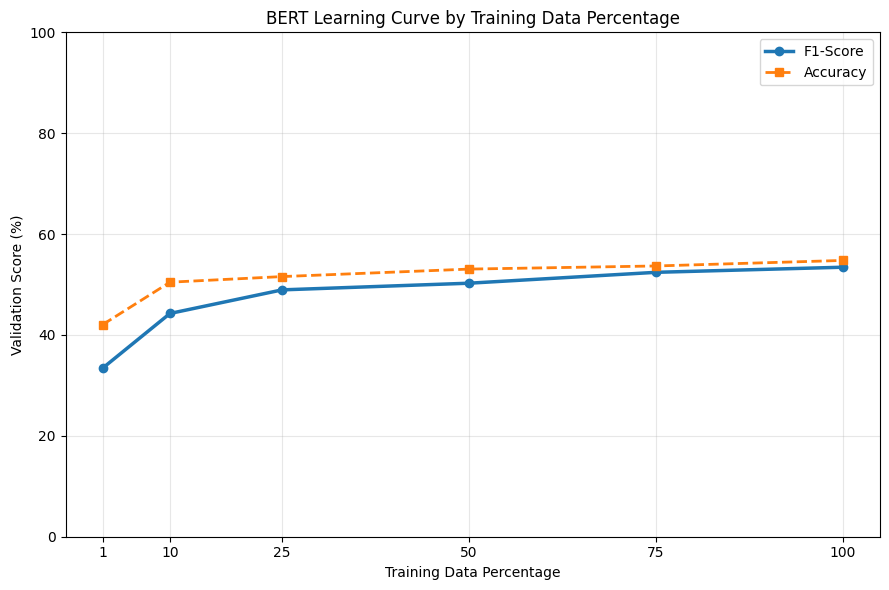

Saved learning curve to ../figures/part3_bert_learning_curve.png

Total runtime: 00:00:00


In [12]:
## plot learning curve
plot_learning_curve(training_percentages, base_results)
total_elapsed = time.time() - total_start
print(f"\nTotal runtime: {format_time(total_elapsed)}")

#### Write up of the learning curve plot:
The learning curve shows how the model's performance (measured by metrics such as F1-Score and Accuracy) changes as the size of the training data increases. 
It increases until plateauing at around 50% for both accuracy and F1-score. This indicates that the model benefits from more data up to a certain point, after which additional data yields diminishing returns in performance improvement.
I see rapid gains early and diminishing returned after 50%. 
This pattern occurs because BERT's pretrained representations are already quite powerful, allowing it to perform well even with limited data. 
However, as the model sees more examples, it can fine-tune its understanding of the specific task, leading to improved performance. 
Once the model has seen enough data to capture the underlying patterns, additional data contributes less to performance gains.
The gap between F1-Score and Accuracy is larger at smaller percentages (25% at 1% data) and narrows as data increases. 
This is because Accuracy can be inflated by the model predicting the majority class more often, while F1 penalizes poor performance on underrepresented classes equally. 
As training data grows, the model sees sufficient examples of each star rating class, reducing this disparity.


### c. Technique Comparison (0.5 points):
Incorporate the techniques tested in Part 2 into your training schema for comparison.

In [13]:
data_dir = Path('../data')

augmented_df = pd.read_csv(data_dir / "augmented_reviews.csv", sep="\t")
augmented_df.rename(columns={'text': 'review', 'star_rating': 'stars'}, inplace=True)

synthetic_df = pd.read_csv(data_dir / "synthetic_filtered.csv")

In [14]:
total_start = time.time()

In [15]:
# BERT with augmented data
augmented_results = run_experiments(
    training_percentages=training_percentages,
    extra_df=augmented_df,
    label='BERT_augmented'
)

Resumed from checkpoint: ['BERT_augmented_1%', 'BERT_augmented_10%', 'BERT_augmented_25%', 'BERT_augmented_50%', 'BERT_augmented_75%', 'BERT_augmented_100%']
Skipping 1% — already in checkpoint
Skipping 10% — already in checkpoint
Skipping 25% — already in checkpoint
Skipping 50% — already in checkpoint
Skipping 75% — already in checkpoint
Skipping 100% — already in checkpoint


In [17]:
# Synthetic BERT (with synthetic data augmentation)
synthetic_results = run_experiments(
    training_percentages=training_percentages,
    extra_df=synthetic_df,
    label='BERT_synthetic'
)

Resumed from checkpoint: ['BERT_synthetic_1%', 'BERT_synthetic_10%', 'BERT_synthetic_25%', 'BERT_synthetic_50%', 'BERT_synthetic_75%', 'BERT_synthetic_100%']
Skipping 1% — already in checkpoint
Skipping 10% — already in checkpoint
Skipping 25% — already in checkpoint
Skipping 50% — already in checkpoint
Skipping 75% — already in checkpoint
Skipping 100% — already in checkpoint


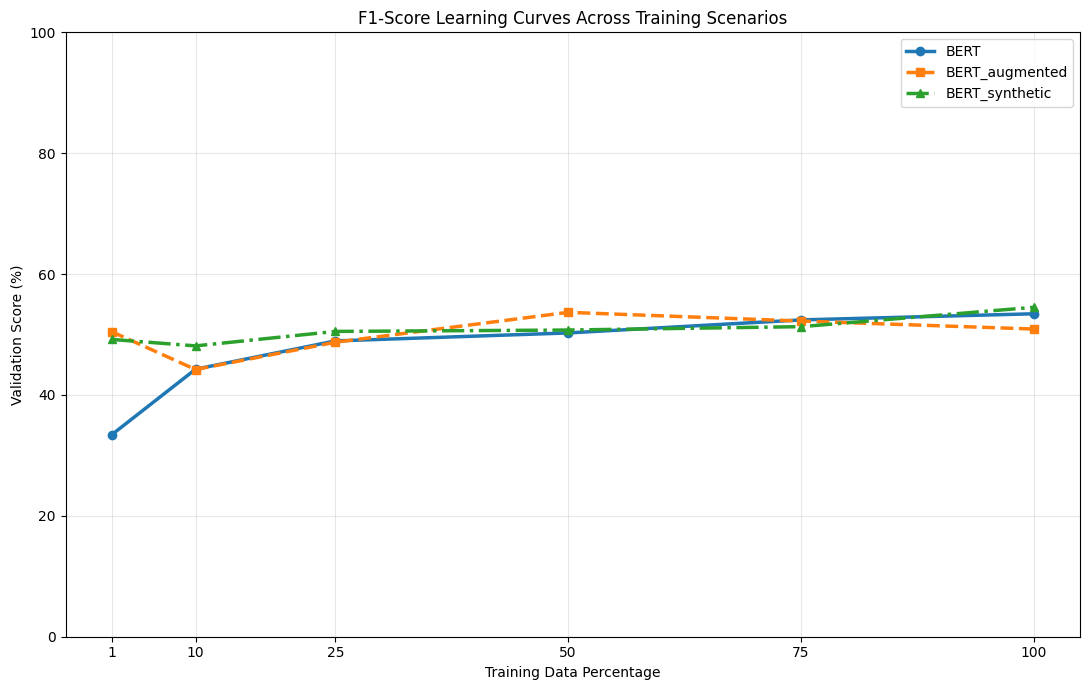

Saved learning curve to ../figures/part3_bert_learning_curve_f1.png


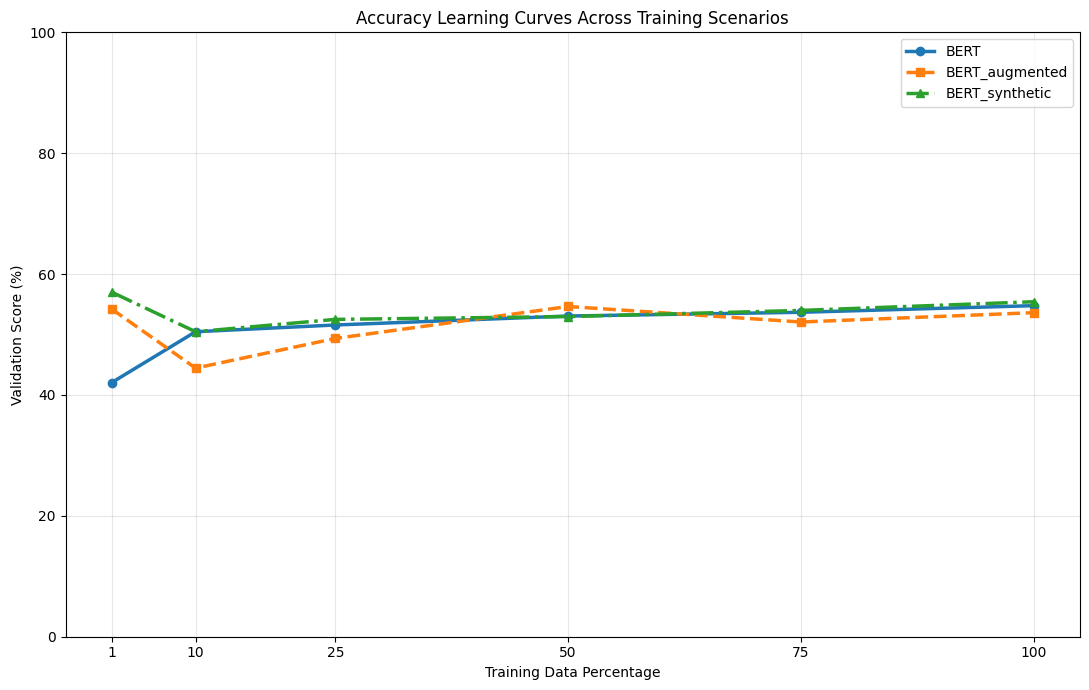

Saved learning curve to ../figures/part3_bert_learning_curve_accuracy.png

Total runtime: 00:00:00


In [18]:
def plot_metric_learning_curves(percentages
                                , results_by_scenario
                                , metric_name
                                , output_filename
                                , title
                                , scenario_styles: dict
                                ):
    """Plot one learning curve metric across multiple scenarios."""
    ordered_percentages = sorted(percentages)

    plt.figure(figsize=(11, 7))



    for scenario_name, style in scenario_styles.items():
        scenario_results = results_by_scenario[scenario_name]
        metric_scores = [
            scenario_results[f'{scenario_name}_{percentage}%'][metric_name]
            for percentage in ordered_percentages
        ]
        plt.plot(
            ordered_percentages,
            metric_scores,
            marker=style['marker'],
            linewidth=2.5,
            linestyle=style['linestyle'],
            color=style['color'],
            label=scenario_name,
        )

    plt.title(title)
    plt.xlabel('Training Data Percentage')
    plt.ylabel('Validation Score (%)')
    plt.xticks(ordered_percentages)
    plt.ylim(0, 100)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    figures_dir.mkdir(exist_ok=True)
    output_path = figures_dir / output_filename
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved learning curve to {output_path}")


scenario_styles = {
    'BERT': {'color': '#1f77b4', 'marker': 'o', 'linestyle': '-'},
    'BERT_augmented': {'color': '#ff7f0e', 'marker': 's', 'linestyle': '--'},
    'BERT_synthetic': {'color': '#2ca02c', 'marker': '^', 'linestyle': '-.'},
}

all_results = {
    'BERT': base_results,
    'BERT_augmented': augmented_results,
    'BERT_synthetic': synthetic_results,
}


plot_metric_learning_curves(
    training_percentages,
    all_results,
    metric_name='F1-Score',
    output_filename='part3_bert_learning_curve_f1.png',
    title='F1-Score Learning Curves Across Training Scenarios',
    scenario_styles=scenario_styles
)
plot_metric_learning_curves(
    training_percentages,
    all_results,
    metric_name='Accuracy',
    output_filename='part3_bert_learning_curve_accuracy.png',
    title='Accuracy Learning Curves Across Training Scenarios',
    scenario_styles=scenario_styles
)

total_elapsed = time.time() - total_start
print(f"\nTotal runtime: {format_time(total_elapsed)}")

In [19]:
#show all results in a table
def display_results_table(results_dict, metric_name):
    """Display results in a tabular format for a specific metric."""
    table_data = []
    for scenario, results in results_dict.items():
        row = [scenario]
        for percentage in sorted(training_percentages):
            key = f"{scenario}_{percentage}%"
            score = results[key][metric_name]
            row.append(f"{score:.2f}")
        table_data.append(row)

    # Create a DataFrame for better visualization
    columns = ['Scenario'] + [f"{p}%" for p in sorted(training_percentages)]
    results_df = pd.DataFrame(table_data, columns=columns)
    print(f"\nResults Table for {metric_name}:\n")
    print(results_df.to_string(index=False))

display_results_table(all_results, 'F1-Score')
display_results_table(all_results, 'Accuracy')


Results Table for F1-Score:

      Scenario    1%   10%   25%   50%   75%  100%
          BERT 33.43 44.26 48.94 50.26 52.42 53.43
BERT_augmented 50.47 44.21 48.72 53.67 52.23 50.91
BERT_synthetic 49.19 48.12 50.51 50.74 51.30 54.51

Results Table for Accuracy:

      Scenario    1%   10%   25%   50%   75%  100%
          BERT 42.06 50.46 51.58 53.06 53.68 54.78
BERT_augmented 54.21 44.44 49.35 54.64 52.07 53.62
BERT_synthetic 57.01 50.46 52.50 52.97 53.99 55.43


At 1% data, augmentation and synthetic data help significantly. BERT alone is at 33% F1 and 42% accuracy, while augmented/synthetic start at ~50% F1 and ~54-57% accuracy. This is the main value proposition of data augmentation, it compensates when original data is scarce. After 10% , all three lines converge and stay within ~3-5% of each other for both metrics. The augmentation advantage essentially disappears as more original data becomes available. Especially by 50% all three are practically the same accuracy. 
Interestingly in this run augmented dropped for 100% 3-4% less than the other in F1, but in accuracy it remained practically the same as other. 

At 100%, base BERT actually edges out augmented F1(53% vs 50%), suggesting that at full data scale, augmented data adds slight noise rather than signal. Although they are all pretty equal in accuracy since 10% of data. 

The dip at 10% for Bert augmented is interesting. It could possible be variance from the train/validation split.

This exercise showed that data augmentation is most valuable in the low-data regime and becomes redundant as original training data grows. Once the accuracy or F1 score platenus as seen in the original elbow curve the augemented/synthetic data do not help increase accuracy further. 

## best model : 100 % data rerun

Labeled rows: 10776
Train: 8620 | Valid: 2156


Map:   0%|          | 0/8620 [00:00<?, ? examples/s]

Map:   0%|          | 0/2156 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/Users/isa.adls/Docume

...

/Users/isa.adls/Documents/BSE_coursework/Advanced_NLP/advanced_nlp_final/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ../models/best_bert_100


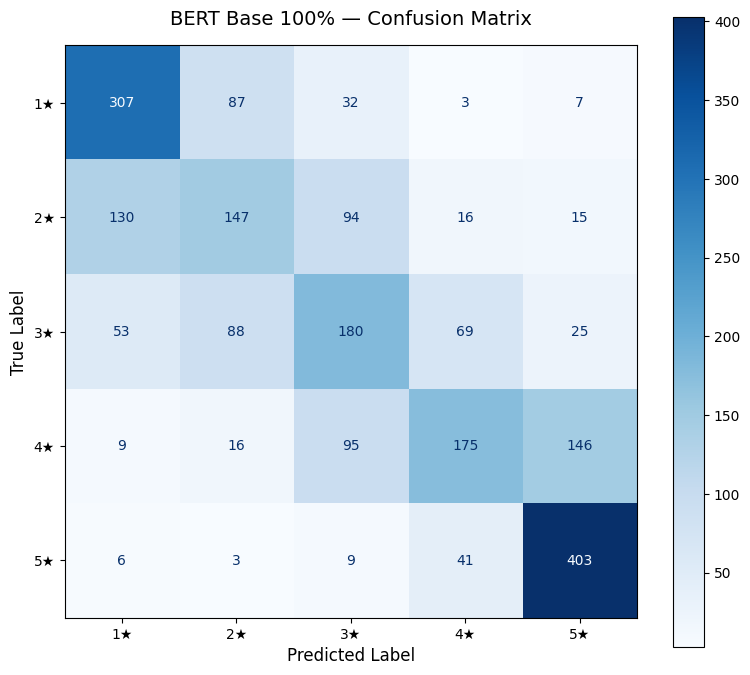

Saved confusion matrix to ../figures/confusion_matrix_best_model.png

Per-class accuracy:
  1★: 70.4%
  2★: 36.6%
  3★: 43.4%
  4★: 39.7%
  5★: 87.2%
Predictions saved to best_model_predictions.json


In [20]:
# Load and preprocess 100% data
df = pd.read_csv(data_dir / 'filtered_reviews_100percent.csv')
df['review'] = df['review'].apply(preprocess_for_bert)
labeled_df = df.dropna(subset=['stars', 'review'])
print(f"Labeled rows: {labeled_df.shape[0]}")

texts = labeled_df['review'].tolist()
labels = (labeled_df['stars'].astype(int) - 1).tolist()

train_texts, valid_texts, train_labels, valid_labels = train_test_split(
    texts, labels, test_size=0.2, stratify=labels, random_state=SEED
)

print(f"Train: {len(train_texts)} | Valid: {len(valid_texts)}")

# Train and save best model
best_model, _, valid_preds = train_bert(
    train_texts, train_labels,
    valid_texts, valid_labels,
    num_train_epochs=20,
    num_labels=5,
    early_stopping=True,
    output_dir='./tmp_bert_best_100',
    save_model_path=str(model_dir / 'best_bert_100')
)

# Confusion matrix
cm = confusion_matrix(valid_labels, valid_preds)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['1★', '2★', '3★', '4★', '5★']
)

fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(cmap='Blues', ax=ax, colorbar=True)
ax.set_title('BERT Base 100% — Confusion Matrix', fontsize=14, pad=15)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig(figures_dir / 'confusion_matrix_best_model.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved confusion matrix to {figures_dir / 'confusion_matrix_best_model.png'}")

# Print per-class accuracy
print("\nPer-class accuracy:")
per_class = cm.diagonal() / cm.sum(axis=1)
for i, acc in enumerate(per_class):
    print(f"  {i+1}★: {acc*100:.1f}%")

# Save predictions for later use
results = {
    'valid_labels': valid_labels,
    'valid_preds': valid_preds.tolist(),
}
with open(data_dir / 'best_model_predictions.json', 'w') as f:
    json.dump(results, f)
print("Predictions saved to best_model_predictions.json")


Ran the confusion matrix to compare to the SOTA literature which also classified predictions by how far off the predictions were from true label. We can see that 5 and 1 stars are the easiest to rank as expected. But also most wrong guesses are one away from the real guess.

In [21]:
def offby_counts(preds):
    dist  = np.abs(preds - y_true)
    wrong = dist[dist > 0]
    c1 = int((wrong == 1).sum())
    c2 = int((wrong == 2).sum())
    c3 = int((wrong >= 3).sum())            # fold 3 and 4 together
    return c1, c2, c3, int(wrong.size)

## get the off-by counts for the best model
y_true = np.array(valid_labels)
y_pred = np.array(valid_preds)
c1, c2, c3, total_wrong = offby_counts(y_pred)
print(f"\nOff-by counts for the best model:")
print(f"  Off by 1: {c1} ({c1/total_wrong*100:.1f}%)")
print(f"  Off by 2: {c2} ({c2/total_wrong*100:.1f}%)")
print(f"  Off by 3 or more: {c3} ({c3/total_wrong*100:.1f}%)")


Off-by counts for the best model:
  Off by 1: 750 (79.4%)
  Off by 2: 151 (16.0%)
  Off by 3 or more: 43 (4.6%)


In [22]:
## accuracy of best model
best_model_accuracy = (y_pred == y_true).mean()
print(f"\nBest model accuracy: {best_model_accuracy*100:.2f}%")


Best model accuracy: 56.22%


In [ ]:
results = {
    'valid_labels': valid_labels,
    'valid_preds': valid_preds.tolist(),
}

In [25]:
metrics_val.run(valid_labels, valid_preds, 'best_model')

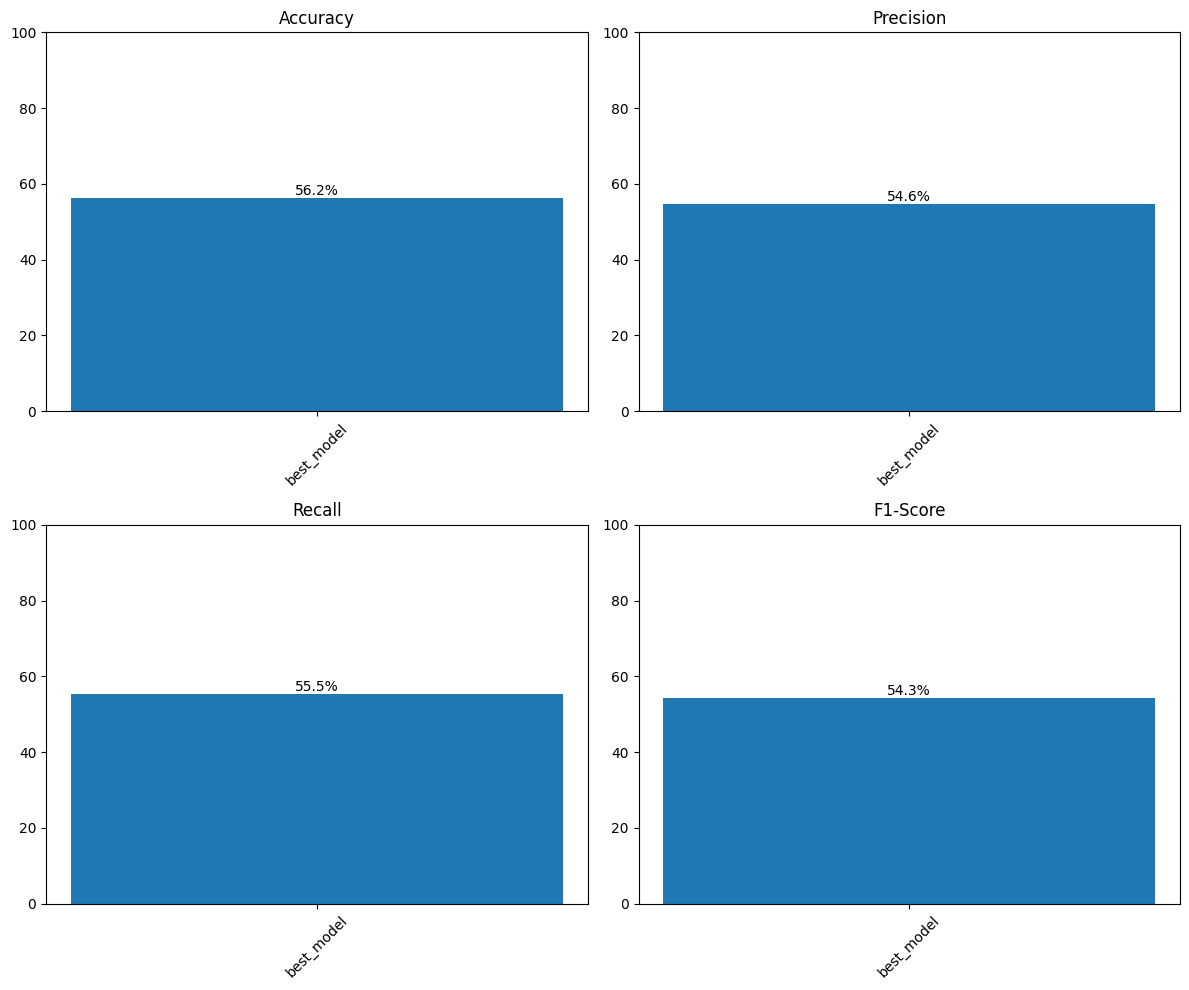

In [26]:
metrics_val.plot()

## d. Methodology Analysis (1 point):
Analyze and compare all methods employed. Discuss the effectiveness and limitations observed.

We trained BERT on increasing percentages of the dataset (1%, 10%, 25%, 50%, 75%, and 100%) and evaluated performance using F1-Score and Accuracy. We then incorporated synthetic and EDA-augmented data into each training scenario to assess the impact of data augmentation across data scales.

**Learning curve findings.** Base BERT improves monotonically across all percentages, reaching 53.43% F1 and 54.78% accuracy at 100%. Both augmentation strategies provide a strong boost at 1% of data — synthetic reaches 49.19% F1 & 57% Accuracy, augmented reached 50.47 F1 & 54.21 Accuracy vs 33.43% F1 and 42.06 Accuracy for base BERT— but this advantage disappears by 25% and all three scenarios converge by 50%. Synthetic data shows high variance across percentages, while base BERT is the most stable. The results suggests augmentation (whether synthetic or augmented) compensates for data scarcity but introduces noise that limits gains at larger scales and become redudant once we have enough data.

**Comparison to Part 2.**  Even with 100% of the training data, base BERT (F1: 53.43%) does not reach the best Part 2 result. SetFit with combined augmentation achieved F1: 62.0% and accuracy: 64.0% using only 32 labeled examples. This demonstrates that model architecture matters more than data quantity for this task — SetFit's contrastive fine-tuning extracts substantially more signal from limited labels than standard BERT fine-tuning even with full data access.

**Limitations of each approach.** 
EDA augmentation (2b): introduces noise by randomly swapping and deleting words, which can corrupt sentiment-bearing terms and create contradictory training examples
LLM synthetic data (2d): expensive to generate at scale, and GPT-generated reviews tend to be more neutral and grammatically uniform than real reviews, creating a distribution mismatch with authentic user-generated content
Zero-shot LLM (2c): no task-specific learning, highly sensitive to prompt wording, and particularly inconsistent on middle star ratings (2-4 stars) where sentiment boundaries are ambiguous
SetFit (2e): requires a compatible sentence-transformer environment, contrastive training is computationally expensive per run, and its advantage over BERT diminishes as labeled data grows

**Production recommendation.**  For a production system with limited labels, SetFit with combined augmentation is the recommended approach — it achieves 62% F1 with only 32 labeled examples, requires no full dataset, and offers fast inference. 

For Part 4 distillation, base BERT at 100% was selected as the teacher model due to its consistent monotonic improvement and well-calibrated probability distributions, which produce richer soft targets for the student than a higher-variance model would.
Comparison to state of the art. Our best result of 55% accuracy falls below two relevant benchmarks. SentiLARE achieves 71.57% on Yelp-5 (5-class), but closes this gap through sentiment-aware pretraining on 6.6M Yelp reviews with POS embeddings and SentiWordNet integration — resources and compute far beyond this project's scope. Pang & Lee (2005) achieve 65-67% on 4-class movie reviews using metric labeling with positive-sentence percentage similarity. Our 55% on the harder 5-class Trustpilot task is comparable when accounting for the additional class granularity, and aligns with their finding that human annotators themselves only score around 55% accuracy. 